# 06 — Síntese

Este notebook fecha o estudo. Reúne as quatro dimensões num plot integrado, propõe um **score híbrido transparente** em três variantes (você escolhe qual peso atribui a cada eixo) e termina com uma recomendação por perfil de uso.

A ordem aqui inverte a lógica dos anteriores: lá tratamos cada eixo isoladamente; aqui forçamos a comparação simultânea. É o lugar do TCC para responder, em uma frase, "qual modelo eu recomendo".


In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle, Wedge, Patch
from matplotlib.lines import Line2D

from utils import (carregar_dados, agrega_por_modelo, estilo_padrao,
                   CORES_PROVEDOR, ORDEM_MODELOS, normalizar_minmax,
                   titulo_acima, anota_sem_sobrepor, legenda_provedor_origem)

estilo_padrao()
df = carregar_dados()
mestre = agrega_por_modelo(df)

## 1. As quatro dimensões num plot só

O gráfico abaixo é o herdeiro do `07_quatro_dimensoes` da v2. **Funcionamento.** Cada modelo é uma marca posicionada em (concisão, acurácia factual) — os dois eixos principais. A marca é dividida ao meio:

- **Lado esquerdo** colore a **latência** (mais escuro = mais lento). Modelos via chat web ficam em cor mostarda, porque latência não foi medida nesse canal.
- **Lado direito** colore o **custo** (mais escuro = mais caro). Chat web aparece em tom claro extremo, porque a métrica não se aplica.

Bolinha = API; quadrado = chat web. Cada eixo da escala tem sua própria colorbar, ambas em rodapé, com paletas distintas (azul-ardósia para tempo, terracota para dinheiro).


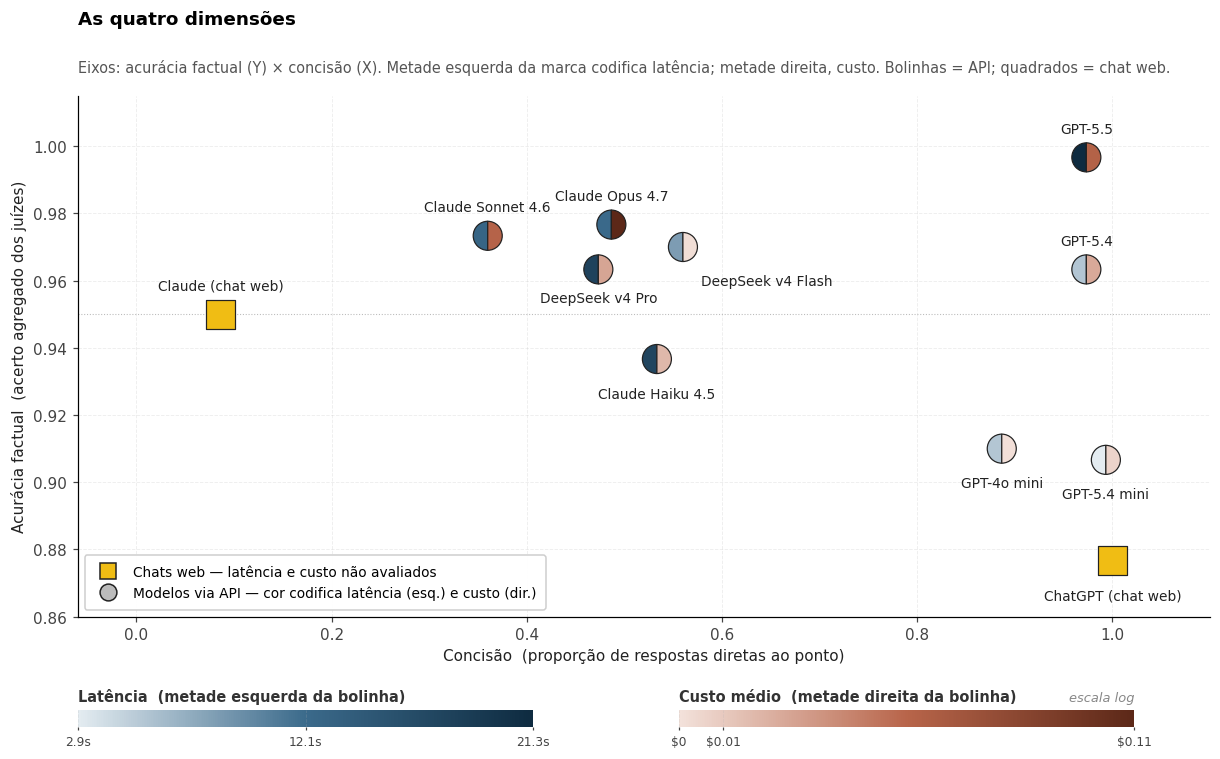

In [17]:
# Paletas sequenciais distintas
cmap_lat  = LinearSegmentedColormap.from_list('lat',
    ['#E4ECF1', '#3B6A8B', '#0E2B40'])
cmap_cost = LinearSegmentedColormap.from_list('cost',
    ['#F3E2DB', '#B8654A', '#5C2818'])

# Para o custo, log1p acomoda zeros (chats web)
mestre['custo_plot'] = mestre['custo_usd'].fillna(0.0)
custo_log = np.log1p(mestre['custo_plot'])
norm_custo = Normalize(vmin=custo_log.min(), vmax=custo_log.max())

# Latência: só nos modelos com medição
lat_validas = mestre['latencia_s'].dropna()
norm_lat = Normalize(vmin=lat_validas.min(), vmax=lat_validas.max())

COR_NAO_MEDIDA = "#F0BD14"  # mostarda — chats não foram avaliados em latência nem custo

fig, ax = plt.subplots(figsize=(11.5, 7.4))
ax.set_xlim(-0.06, 1.10)
ax.set_ylim(0.86, 1.015)

RAIO_PT = 9.5  # raio do marcador em pontos
trans_pt = (mtransforms.Affine2D().scale(1/72.0) + fig.dpi_scale_trans)

# Acumuladores:
#   - API: dois hemisférios por ponto (esquerda = latência, direita = custo)
#   - Chat web: um único quadrado preenchido em mostarda (sem divisão)
pe, pd_ = [], []          # hemisférios da API
ce, cd = [], []           # cores dos hemisférios
oe = []                   # offsets dos pontos da API

q_full = []               # quadrados completos dos chats
oq = []                   # offsets dos chats

for _, row in mestre.iterrows():
    x, y = row['concisao'], row['precisao']
    if row['origem'] == 'Chat web':
        # Quadrado inteiro em mostarda, sem divisão
        q_full.append(Rectangle((-RAIO_PT, -RAIO_PT), 2*RAIO_PT, 2*RAIO_PT))
        oq.append((x, y))
    else:
        cl = cmap_lat(norm_lat(row['latencia_s']))
        cc = cmap_cost(norm_custo(np.log1p(row['custo_plot'])))
        pe.append(Wedge((0, 0), RAIO_PT,  90, 270))
        pd_.append(Wedge((0, 0), RAIO_PT, -90,  90))
        ce.append(cl)
        cd.append(cc)
        oe.append((x, y))

def add(patches, cores, offs):
    if not patches:
        return
    ax.add_collection(PatchCollection(
        patches, facecolors=cores, edgecolors='#222', linewidths=0.8,
        offsets=offs, transOffset=ax.transData,
        transform=trans_pt, zorder=4))

# API: dois hemisférios (latência + custo)
add(pe, ce, oe)
add(pd_, cd, oe)

# Chat web: quadrado inteiro em mostarda
add(q_full, [COR_NAO_MEDIDA] * len(q_full), oq)

# Rótulos com offsets manuais (editáveis)
offsets_lab = {
    'GPT-5.5':            ( 0,  14, 'center', 'bottom'),
    'GPT-5.4':            ( 0,  14, 'center', 'bottom'),
    'GPT-5.4 mini':       ( 0, -18, 'center', 'top'),
    'GPT-4o mini':        ( 0, -18, 'center', 'top'),
    'Claude Opus 4.7':    ( 0,  14, 'center',  'bottom'),
    'Claude Sonnet 4.6':  ( 0,  14, 'center', 'bottom'),
    'Claude Haiku 4.5':   ( 0, -18, 'center', 'top'),
    'DeepSeek v4 Flash':  ( 12, -18, 'left',   'top'),
    'DeepSeek v4 Pro':    (0,  -14, 'center',  'top'),
    'ChatGPT (chat web)': ( 0, -18, 'center', 'top'),
    'Claude (chat web)':  ( 0,  14, 'center',   'bottom'),
}
for nome, row in mestre.iterrows():
    dx, dy, ha, va = offsets_lab.get(nome, (0, 14, 'center', 'bottom'))
    ax.annotate(nome, xy=(row['concisao'], row['precisao']),
                xytext=(dx, dy), textcoords='offset points',
                ha=ha, va=va, fontsize=9, color='#222')

ax.axhline(0.95, ls=':', color='#bbb', lw=0.7, zorder=1)
ax.set_xlabel('Concisão  (proporção de respostas diretas ao ponto)')
ax.set_ylabel('Acurácia factual  (acerto agregado dos juízes)')

# Legenda no canto inferior esquerdo: quadrado mostarda (chats) e bolinha (API)
legenda_marcadores = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor=COR_NAO_MEDIDA,
           markeredgecolor='#222', markersize=11,
           label='Chats web — latência e custo não avaliados'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#bbb',
           markeredgecolor='#222', markersize=11,
           label='Modelos via API — cor codifica latência (esq.) e custo (dir.)'),
]
ax.legend(handles=legenda_marcadores, loc='lower left', fontsize=9,
          frameon=True, framealpha=0.95, edgecolor='#ccc',
          handletextpad=0.8, borderpad=0.7)

titulo_acima(ax,
    'As quatro dimensões',
    'Eixos: acurácia factual (Y) × concisão (X). '
    'Metade esquerda da marca codifica latência; metade direita, custo. '
    'Bolinhas = API; quadrados = chat web.')

# Colorbars duplas no rodapé
fig.subplots_adjust(top=0.86, bottom=0.22, left=0.075, right=0.97)

cax_lat  = fig.add_axes([0.075, 0.085, 0.36, 0.020])
cax_cost = fig.add_axes([0.55,  0.085, 0.36, 0.020])

sm_l = ScalarMappable(norm=norm_lat, cmap=cmap_lat); sm_l.set_array([])
cb_l = fig.colorbar(sm_l, cax=cax_lat, orientation='horizontal')
tk_l = [norm_lat.vmin, (norm_lat.vmin + norm_lat.vmax) / 2, norm_lat.vmax]
cb_l.set_ticks(tk_l); cb_l.set_ticklabels([f'{v:.1f}s' for v in tk_l])
cb_l.ax.tick_params(labelsize=8, length=2); cb_l.outline.set_visible(False)
cax_lat.text(0,   1.6, 'Latência  (metade esquerda da bolinha)',
    transform=cax_lat.transAxes, fontsize=9.5, color='#333',
    ha='left', weight='bold')

sm_c = ScalarMappable(norm=norm_custo, cmap=cmap_cost); sm_c.set_array([])
cb_c = fig.colorbar(sm_c, cax=cax_cost, orientation='horizontal')
ticks_usd = [0.000, 0.010, 0.107]
cb_c.set_ticks([np.log1p(v) for v in ticks_usd])
cb_c.set_ticklabels(['$0', '$0.01', '$0.11'])
cb_c.ax.tick_params(labelsize=8, length=2); cb_c.outline.set_visible(False)
cax_cost.text(0,   1.6, 'Custo médio  (metade direita da bolinha)',
    transform=cax_cost.transAxes, fontsize=9.5, color='#333',
    ha='left', weight='bold')
cax_cost.text(1.0, 1.6, 'escala log',
    transform=cax_cost.transAxes, fontsize=8.5, color='#888',
    ha='right', style='italic')

plt.show()


**Como ler o plot.**

- Olhe primeiro a **posição** do ponto: alta no Y é preciso, alta no X é conciso.
- Depois olhe a **cor**: lado esquerdo escuro = lento; lado direito escuro = caro.
- A combinação ideal de cores é: lado esquerdo claro + lado direito claro. **Quem chega mais perto disso é DeepSeek v4 Flash** — claro nos dois lados, alta no Y e razoável no X.
- O extremo oposto (lado esquerdo escuro + lado direito escuro) é o **Claude Opus 4.7**: acurácia factual alta, mas lento e o mais caro.
- **GPT-5.5** tem lado direito escuro (caro), mas o esquerdo também é escuro (lento) — o preço da acurácia factual suprema.

Esse é o painel-resumo do estudo. Tudo o que vem a seguir já está implícito nele.


## 2. Score híbrido transparente

Três receitas para sintetizar tudo em um número. Em todas, cada dimensão é normalizada para [0, 1] (sendo 1 = melhor) antes da combinação. Latência e custo só existem para a API; nos chats web aparecem como "—".

**Fórmulas explícitas, sem caixa-preta**:

- **Score-Q (qualidade primeiro)**: `0.6 · acurácia factual + 0.4 · concisão`. Ignora custo e latência. Use quando a aplicação não tem restrição operacional.
- **Score-P (produção balanceada)**: `0.4 · acurácia factual + 0.2 · concisão + 0.2 · velocidade + 0.2 · economia`. Pondera as quatro dimensões, com peso maior para acurácia factual. Use em produção típica.
- **Score-E (econômico)**: `0.3 · acurácia factual + 0.1 · concisão + 0.2 · velocidade + 0.4 · economia`. Peso pesado em custo. Use para volume alto / orçamento apertado.

Onde:
- `velocidade = 1 − norm(latência)` (latência baixa → velocidade alta)
- `economia = 1 − norm(log(custo))` (custo baixo → economia alta)


In [ ]:
def normalizar(s, invertir=False):
    return normalizar_minmax(s, invertir=invertir)

# Para chats web, latência e custo são NaN — tratamos os scores separadamente
api_idx  = mestre['origem'] == 'API'

# Normalizações
mestre['n_precisao']  = normalizar(mestre['precisao'])
mestre['n_concisao']  = normalizar(mestre['concisao'])

# Velocidade e economia: só na API. Renormalizadas em [0, 1] dentro de API.
mestre.loc[api_idx, 'n_velocidade'] = normalizar(
    mestre.loc[api_idx, 'latencia_s'], invertir=True)
mestre.loc[api_idx, 'n_economia']   = normalizar(
    np.log(mestre.loc[api_idx, 'custo_usd']), invertir=True)

# Scores
mestre['score_Q'] = (0.6 * mestre['n_precisao']
                   + 0.4 * mestre['n_concisao'])

mestre['score_P'] = np.where(api_idx,
    0.4 * mestre['n_precisao']
  + 0.2 * mestre['n_concisao']
  + 0.2 * mestre['n_velocidade'].fillna(0)
  + 0.2 * mestre['n_economia'].fillna(0),
    np.nan)

mestre['score_E'] = np.where(api_idx,
    0.3 * mestre['n_precisao']
  + 0.1 * mestre['n_concisao']
  + 0.2 * mestre['n_velocidade'].fillna(0)
  + 0.4 * mestre['n_economia'].fillna(0),
    np.nan)

# Tabela final
tabela = mestre[['provedor', 'origem',
                 'precisao', 'concisao', 'latencia_s', 'custo_usd',
                 'score_Q', 'score_P', 'score_E']].copy()

tabela_view = tabela.copy()
tabela_view['precisao']  = (tabela['precisao']*100).round(1).astype(str) + '%'
tabela_view['concisao']  = (tabela['concisao']*100).round(1).astype(str) + '%'
tabela_view['latencia_s'] = tabela['latencia_s'].apply(
    lambda v: '—' if pd.isna(v) else f'{v:.1f}s')
tabela_view['custo_usd']  = tabela['custo_usd'].apply(
    lambda v: '—' if pd.isna(v) else f'${v:.4f}')
for c in ['score_Q', 'score_P', 'score_E']:
    tabela_view[c] = tabela[c].apply(lambda v: '—' if pd.isna(v) else f'{v:.3f}')

tabela_view

## 3. Ranking lado a lado pelos três scores

Para visualizar quem se beneficia de cada ponderação.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.4), sharey=False,
                         layout='constrained')

cenarios = [
    ('score_Q', 'Score-Q  (qualidade)',
     'acurácia factual 60% + concisão 40%'),
    ('score_P', 'Score-P  (produção balanceada)',
     '0.4 prec + 0.2 conc + 0.2 vel + 0.2 econ'),
    ('score_E', 'Score-E  (economia)',
     '0.3 prec + 0.1 conc + 0.2 vel + 0.4 econ'),
]

for ax, (col, titulo, sub) in zip(axes, cenarios):
    sub_df = mestre[['provedor', 'origem', 'cor', col]].dropna(subset=[col])
    sub_df = sub_df.sort_values(col, ascending=True)

    cores  = sub_df['cor'].values
    canais = sub_df['origem'].values
    xs = np.arange(len(sub_df))

    bars = ax.barh(xs, sub_df[col].values, color=cores, edgecolor='#222',
                   linewidth=0.7, height=0.72)
    for b, c in zip(bars, canais):
        if c == 'Chat web':
            b.set_hatch('///')

    # Rótulos numéricos no topo das barras
    for x, v in zip(xs, sub_df[col].values):
        ax.text(v + 0.012, x, f'{v:.2f}', va='center',
                fontsize=9, color='#222')

    # Rótulos no eixo Y de CADA painel (ordem própria do cenário)
    ax.set_yticks(xs)
    ax.set_yticklabels(sub_df.index, fontsize=9)
    ax.set_xlim(0, 1.15)
    ax.set_xlabel('score [0–1]')
    ax.tick_params(axis='y', length=0)

    titulo_acima(ax, titulo, sub, y_titulo=1.07, y_subtitulo=1.015)

plt.show()

**Quem vence em cada cenário.**

- **Score-Q (qualidade pura)**: o pódio é **GPT-5.5 (0,99)** seguido a alguma distância de **GPT-5.4 (0,82)**. A receita pondera só acurácia factual e concisão; GPT-5.5 acerta as duas pontas. Os chats web aparecem no fim da lista (0,40 e 0,37) — a acurácia factual baixa de ChatGPT (chat web) anula sua concisão recorde, e a verbosidade extrema do Claude (chat web) penaliza tudo.
- **Score-P (produção balanceada)**: o ranking se reorganiza completamente. **DeepSeek v4 Flash (0,74)** assume a liderança, seguido por **GPT-5.4 (0,72)** e **GPT-4o mini (0,66)**. GPT-5.5 cai para o 5º lugar (0,63), porque a sua excelência em acurácia factual é canibalizada pelo custo (US$ 0,055) e pela latência (21 s).
- **Score-E (custo prioritário)**: **DeepSeek v4 Flash (0,79) domina absoluto**, com GPT-4o mini (0,74) em segundo. Claude Opus 4.7 cai para último (0,39), porque é o mais caro e um dos mais lentos.

> Repare na **inversão entre Q e E**: Claude Opus 4.7 sai do 3º lugar (Q) para o último (E). O modelo de topo da Anthropic é o melhor onde só importa qualidade, e o pior onde só importa economia.


## 4. Recomendação por perfil de uso

Fechando o estudo:

| Cenário | Modelo recomendado | Por quê |
|---|---|---|
| **Resposta crítica, sem restrição de custo** | GPT-5.5 (API) | Única acurácia factual acima de 99%. Aceite 21 s de latência e US$ 0,055 por consulta. |
| **Atendimento interativo (latência importa)** | DeepSeek v4 Flash | 8,6 s, 97% de acurácia factual, **e** US$ 0,002. Atende tanto velocidade quanto custo. |
| **Volume alto / orçamento limitado** | DeepSeek v4 Flash | Mesma escolha do cenário anterior — domina os dois eixos operacionais simultaneamente. |
| **Aplicação que precisa de respostas explicativas** | Claude Sonnet 4.6 | 321 tokens por resposta em média, com 97,3% de acurácia factual. |
| **Produção generalista, equilibrada** | GPT-5.4 | 96,3% de acurácia factual, 5,7 s, US$ 0,024. Sem extremos em nenhum eixo. |
| **Usuário final, sem implementação** | Claude (chat web) | 95% sem nenhuma instrumentação. Aceite respostas longas. |

**Quando *não* usar cada um.**

- **ChatGPT (chat web)**: para conteúdo de edital, fica em 87,7% de acurácia factual — o pior do estudo. Útil em consulta exploratória, mas o produto comercial OpenAI é, em si, o pior dos canais avaliados para esta tarefa.
- **Claude Haiku 4.5**: apesar de ser "modelo leve", custa US$ 0,017 e leva 17,5 s no contexto agentico — desempenho semelhante ao Sonnet/Opus em tempo, com acurácia factual menor (93,7%). Sonnet 4.6 ou Flash são estritamente melhores.
- **GPT-5.4 mini**: latência muito boa (2,9 s) e custo baixo (US$ 0,006), mas acurácia factual de 90,7%. Se a aplicação tem baixa tolerância a erros, prefira GPT-5.4 ou DeepSeek v4 Flash.
- **Claude Opus 4.7**: acurácia factual excelente (97,7%), mas é o **modelo mais caro** do estudo. Se você não precisa do extra de 0,4 pp sobre o Sonnet, o Sonnet é metade do preço.

---

## Reflexão final

O recorte do TCC mostrou que **a escolha do modelo não é separável da escolha do canal**. Os mesmos dois provedores (OpenAI e Anthropic) entregam, na sua versão comercial pelo navegador, produtos com perfis muito distintos da própria versão via API — em acurácia factual, em concisão, no estilo de redação. Uma comparação que só olhasse "OpenAI vs Anthropic" mascararia o fato de que a instrumentação (RAG + ferramenta de busca) move o resultado mais que a marca.

E, embora as quatro dimensões existam em tensão entre si, há uma frente de pareto-eficiência clara: **DeepSeek v4 Flash, GPT-5.4 e GPT-5.5** definem a fronteira. Os outros modelos são dominados em pelo menos um eixo. DeepSeek v4 Flash, em particular, aparece como vencedor disparado dos cenários operacionais — atende simultaneamente custo, latência e acurácia factual acima de 95%. Para um TCC que avalia uso *prático* de LLMs em consulta a editais, essa é a recomendação central.
